In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("../data/q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


In [5]:
df.isnull().sum()

age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1
...,...,...,...,...,...,...
495,20,22094,13,729,3,1
496,53,63845,1,7371,30,6
497,44,53558,9,906,10,3
498,36,41202,9,2046,47,6


In [7]:
X = df.select_dtypes(include=[np.number])

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

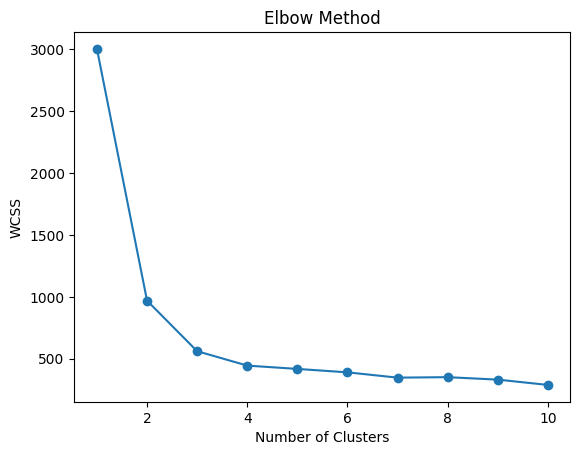

In [9]:
wcss = []
for i in range(1, 11):
   kmeans = KMeans(n_clusters=i, random_state=42)
   kmeans.fit(X_scaled)
   wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

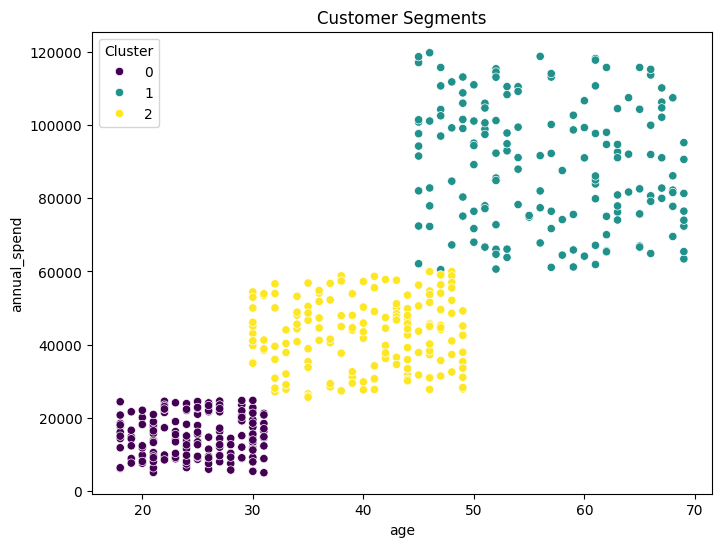

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=df["Cluster"], palette="viridis")
plt.title("Customer Segments")
plt.show()

In [12]:
df.groupby("Cluster").mean()
 

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


## Q2 Conclusion
K-Means clustering was used to segment the dataset into groups based on similarity.
Using the Elbow Method, the optimal number of clusters was identified. After applying clustering, the data was divided into distinct groups with similar characteristics.
This approach helps in identifying patterns and can be useful for decision-making such as customer segmentation or targeted strategies.